# MLflow

## Register model in MLflow Model Registry 

In [ ]:
! pip install tensorflow==2.15 keras==2.15

In [1]:
import kfp
from pathlib import Path
kfp_client = kfp.Client()
namespace = kfp_client.get_user_namespace()
user_mounted_dir_name = namespace
user_shared_dir = f"{str(Path.home())}/{user_mounted_dir_name}/"
model_dir = user_shared_dir + "model_trained/"
train_dir = user_shared_dir + "training/"
model_dir, train_dir

/opt/conda/lib/python3.11/site-packages/kfp/client/client.py:159: FutureWarning: This client only works with Kubeflow Pipeline v2.0.0-beta.2 and later versions.
  warnings.warn(


('/home/ashish-kumarj-hpe.com/ashish-kumarj-h-653cd6af/model_trained/',
 '/home/ashish-kumarj-hpe.com/ashish-kumarj-h-653cd6af/training/')

In [2]:
model_name = "digit-recognition"

In [3]:
#!ls '/home/christian.temporale-hpe.com/christian-temporale-hpe-com-4bdac2aa/model_trained/'

In [4]:
import keras
model = keras.models.load_model(model_dir + "1")

2025-08-19 16:35:12.945015: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-19 16:35:12.950057: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-19 16:35:12.980686: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-19 16:35:12.980710: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-19 16:35:12.981728: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

### Logs the model in ML-flow. This will create a new experiment

In [5]:
import mlflow
import mlflow.tensorflow

with mlflow.start_run() as run:
    # Log the TensorFlow model
    print("mlflow.tensorflow.log_model:")
    mlflow.tensorflow.log_model(model=model, artifact_path="1")

2025/08/19 16:35:15 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


mlflow.tensorflow.log_model:


Assets written to: /tmp/tmp8knloy9o/model/data/model/assets
2025/08/19 16:35:19 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run inquisitive-asp-936 at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/0/runs/c12d286b99b74ce9a750bd173868cbf1
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/0


## Manual steps to be performed in MLflow UI

1. Access the MLflow UI, and select the _Experiments_ tab
2. Select the latest experiment, click on _tensorflow_ model
3. On the following screen, click on _Register model_
4. Select create new model and type "digit-recognition" (in case this model already exists: just select "digit-recognition" from the list)

At this point if you refresh the Experiment tab in MLflow you will see your experiment associated with the "digit-recognition"model. 


## Retrieve model from MLflow Model Registry 

In [6]:
mlflow_client = mlflow.MlflowClient()
model_info = mlflow_client.get_registered_model(model_name)
model_info

<RegisteredModel: aliases={}, creation_timestamp=1755621362457, description='', last_updated_timestamp=1755621362713, latest_versions=[<ModelVersion: aliases=[], creation_timestamp=1755621362713, current_stage='None', description='', last_updated_timestamp=1755621362713, name='digit-recognition', run_id='c12d286b99b74ce9a750bd173868cbf1', run_link='', source='s3://mlflow.pcaihpisra/0/c12d286b99b74ce9a750bd173868cbf1/artifacts/1', status='READY', status_message=None, tags={}, user_id='', version='1'>], name='digit-recognition', tags={}>

In [7]:
latest_model_version = mlflow_client.get_latest_versions(model_name, stages=["None"])[0].version
latest_model_version

/tmp/ipykernel_363/2059420851.py:1: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest_model_version = mlflow_client.get_latest_versions(model_name, stages=["None"])[0].version


'1'

In [8]:
#model_info = mlflow.models.get_model_info(f"models:/{model_name}/{latest_model_version}")

In [9]:
#model_info.model_uri, model_info.model_uuid, model_info.run_id

## Use model fetched from MLflow Model Registry 

Warning: it might take some minutes before the model contents are internally loaded into S3. The load model may fail if all the artifacts are not yet presents in S3.

In [10]:
import mlflow.pyfunc
model_version = 1

In [11]:
mlflow_model = mlflow.pyfunc.load_model(model_uri=f"models:/{model_name}/{latest_model_version}")

In [12]:
import numpy as np
x_test = np.load(train_dir + "xtest-preproc.npy")

### Prediction check

In [13]:
mlflow_model.predict(x_test)

313/313 [==============================] - 1s 4ms/step


array([[4.5385218e-06, 6.6885159e-06, 5.5855501e-04, ..., 9.9904269e-01,
        3.1810257e-05, 8.8691100e-05],
       [5.1898351e-06, 1.2735886e-04, 9.9984574e-01, ..., 3.1776378e-07,
        1.5056334e-05, 1.3583938e-08],
       [5.3803691e-05, 9.9635148e-01, 8.8561018e-04, ..., 7.5523654e-04,
        4.4319144e-04, 1.3816303e-04],
       ...,
       [2.3141747e-07, 7.3720716e-05, 1.0123489e-06, ..., 4.7709789e-05,
        5.7505129e-04, 9.8402204e-04],
       [1.8761871e-07, 2.0757953e-07, 1.0350342e-08, ..., 1.6397688e-07,
        6.0727948e-04, 5.9502722e-06],
       [1.7810083e-04, 4.8099970e-04, 4.2690191e-04, ..., 6.1750447e-06,
        9.8239153e-04, 6.8520685e-06]], dtype=float32)

In [14]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

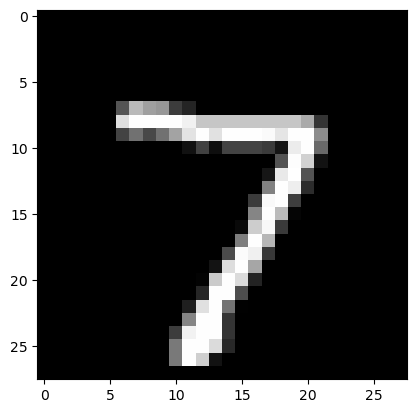

In [15]:
import matplotlib.pyplot as plt
image = x_test[0]

# plot the sample
fig = plt.figure
plt.imshow(image, cmap='gray')
plt.show()

In [16]:
confs = model.predict(np.expand_dims(x_test[0], axis=0))[0]
confs

1/1 [==============================] - 0s 46ms/step


array([4.5385264e-06, 6.6885159e-06, 5.5855501e-04, 2.6155612e-04,
       1.7461005e-06, 3.2302121e-06, 4.8840354e-07, 9.9904269e-01,
       3.1810287e-05, 8.8691013e-05], dtype=float32)

In [17]:
print(f"Digit recognized: {np.where(confs == max(confs))[0][0]}")

Digit recognized: 7


**This concludes the MLFlow check. The following cells can be skipped**

### (Debug only) Inspect S3 contents

In [ ]:
import os, boto3
s3 = boto3.client("s3", verify=False)

In [ ]:
s3.list_buckets()['Buckets']

In [ ]:
s3_model_url = model_info.latest_versions[0].source

In [ ]:
s3_model_bucket = s3_model_url.split('/')[2]

In [ ]:
s3.list_objects_v2(Bucket=s3_model_bucket)